In [4]:
import warnings, os, json
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import seaborn as sns
 
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
import xgboost as xgb

# Configuration

In [5]:
RANDOM_STATE = 42
TEST_SIZE     = 0.20
VAL_SIZE      = 0.15
OUT_DIR       = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
 
PALETTE = {"legit": "#4C72B0", "fraud": "#DD4444"}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
 

In [6]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.size

8829017

# Exploratory Data Analyis

In [8]:

fig = plt.figure(figsize=(20, 22))
fig.suptitle("Fraud Detection — EDA Dashboard", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)
 

<Figure size 2000x2200 with 0 Axes>

### Class Imbalance bar

In [9]:

# 2a. Class imbalance bar
ax1 = fig.add_subplot(gs[0, 0])
counts = df['Class'].value_counts()
bars = ax1.bar(["Legitimate (0)", "Fraud (1)"], counts.values,
               color=[PALETTE["legit"], PALETTE["fraud"]], edgecolor="white", width=0.5)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f"{int(b.get_height())}", ha="center", va="bottom", fontweight="bold")
ax1.set_title("Class Distribution", fontweight="bold")
ax1.set_ylabel("Count")
plt.show()


### amount distribution by class

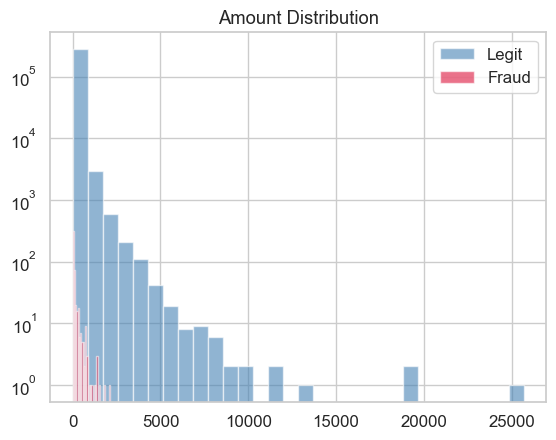

In [10]:
# 5. Amount distribution by class
for cls, lbl, col in [(0,'Legit','steelblue'), (1,'Fraud','crimson')]:
    df[df['Class']==cls]['Amount'].hist(bins=30, alpha=0.6, label=lbl, color=col)
plt.legend(); plt.yscale('log'); plt.title("Amount Distribution"); plt.show()

### Time distribution

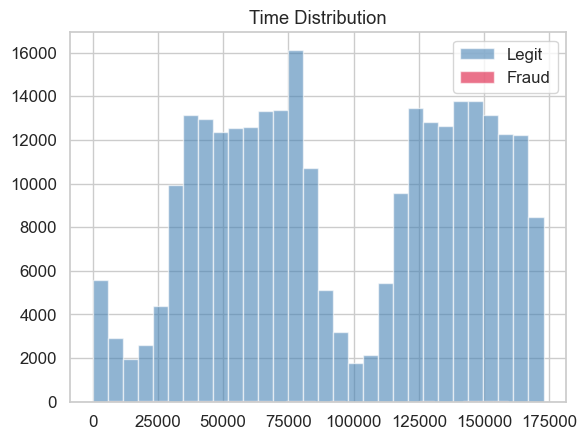

In [11]:
# 6. Time distribution by class
for cls, lbl, col in [(0,'Legit','steelblue'), (1,'Fraud','crimson')]:
    df[df['Class']==cls]['Time'].hist(bins=30, alpha=0.6, label=lbl, color=col)
plt.legend(); plt.title("Time Distribution"); plt.show()

### Box plots

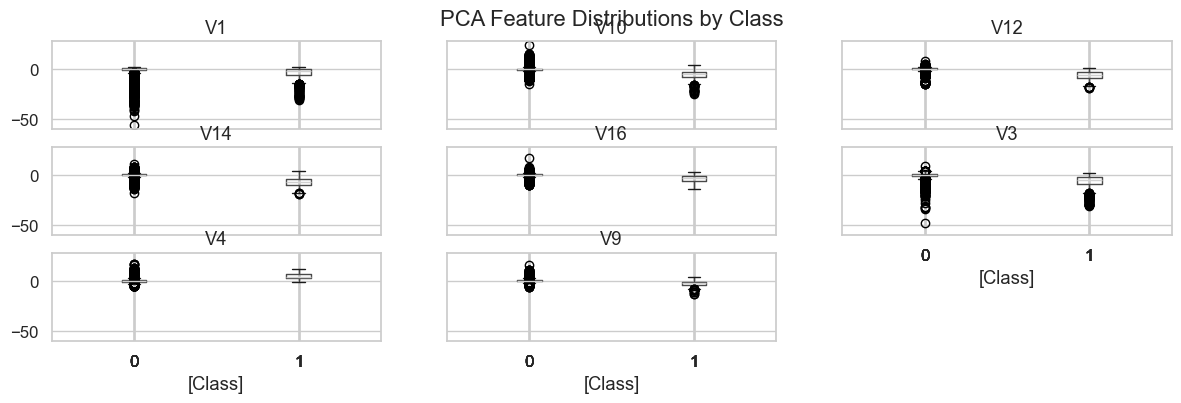

In [12]:
# 7. Boxplots — top PCA features by class
top = ['V1','V3','V4','V9','V10','V12','V14','V16']
df[top + ['Class']].boxplot(by='Class', figsize=(14, 4))
plt.suptitle("PCA Feature Distributions by Class"); plt.show()

### Correlation

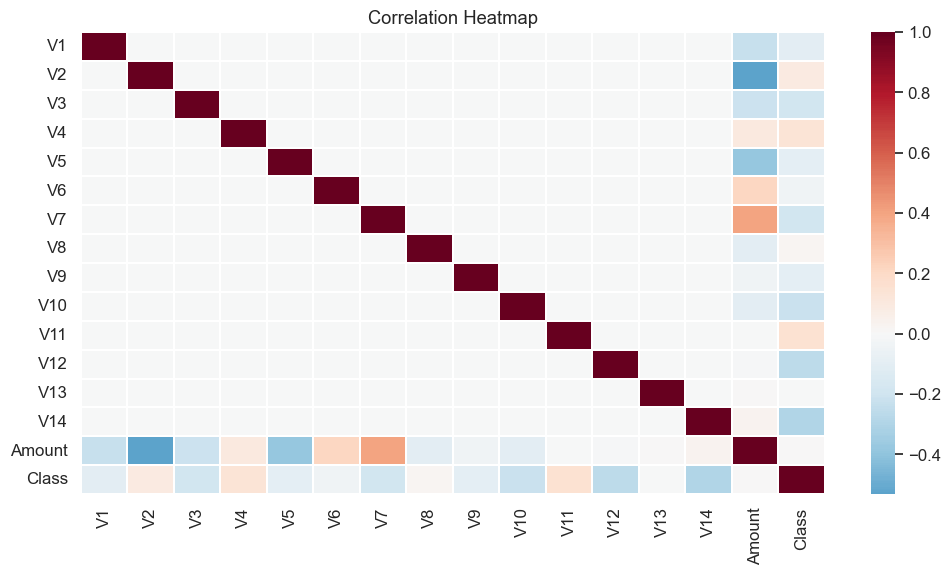

In [13]:
# 8. Correlation heatmap
v_cols = [c for c in df.columns if c.startswith('V')][:14]
corr = df[v_cols + ['Amount','Class']].corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, linewidths=0.3)
plt.title("Correlation Heatmap"); plt.show()

### Mean difference

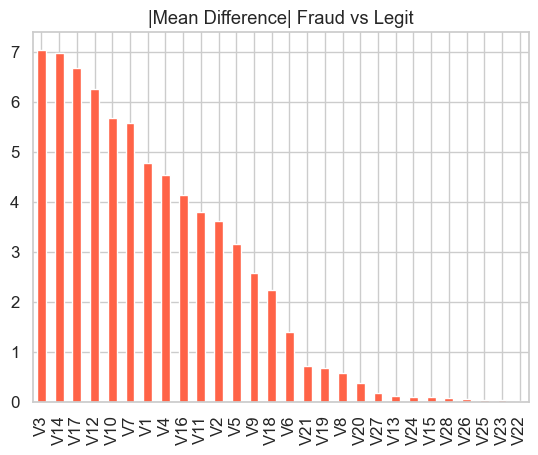

In [14]:
# 9. Mean difference (discriminability proxy)
v_all = [c for c in df.columns if c.startswith('V')]
diff = (df[df['Class']==1][v_all].mean() - df[df['Class']==0][v_all].mean()).abs()
diff.sort_values(ascending=False).plot(kind='bar', color='tomato')
plt.title("|Mean Difference| Fraud vs Legit"); plt.show()

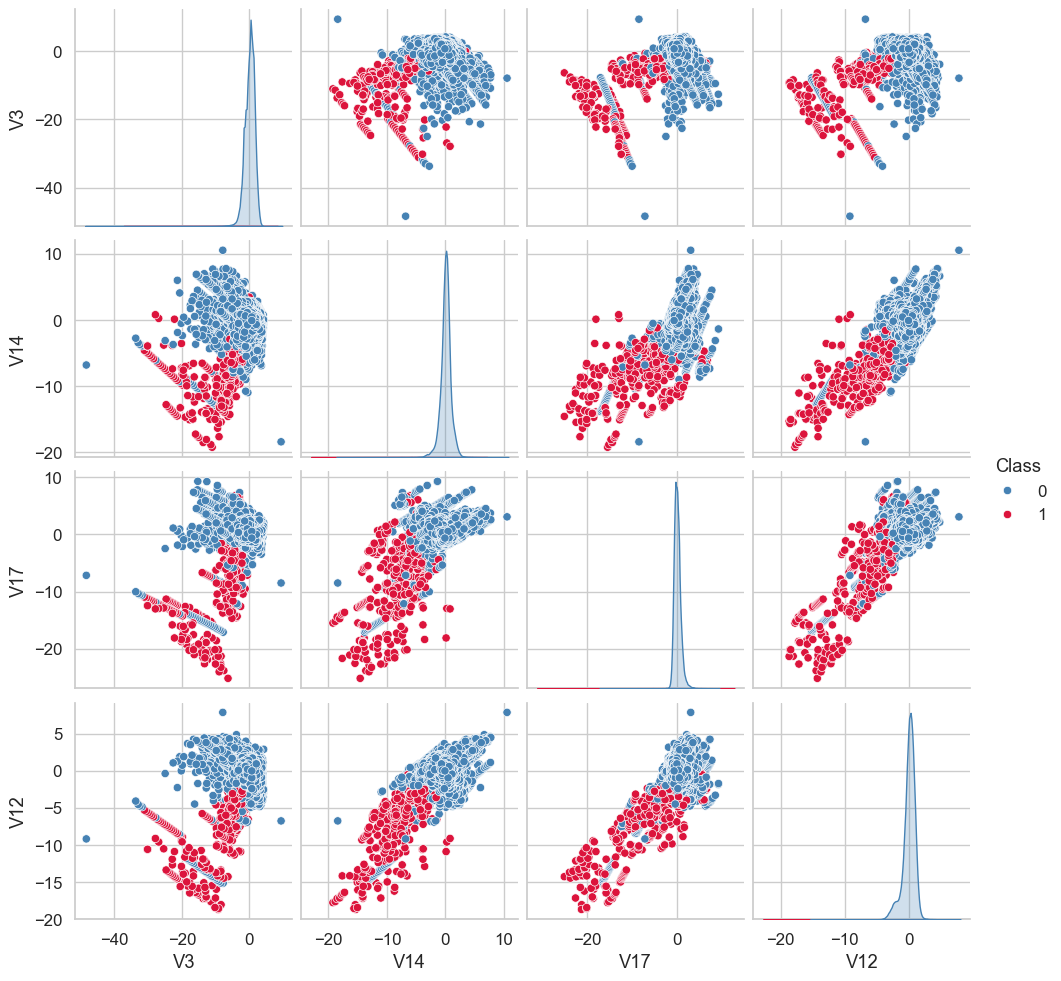

In [15]:
# 10. Pairplot — top 4 most discriminative features
top4 = diff.sort_values(ascending=False).head(4).index.tolist()
sns.pairplot(df[top4 + ['Class']], hue='Class', palette={0:'steelblue', 1:'crimson'})
plt.show()

# Feature Engineering

In [16]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    8 engineered features with documented rationale.
    All operations are deterministic / reproducible.
    """
    d = df.copy()
 
    # ── FE-1: log1p(Amount)
    # Rationale: Amount is right-skewed (max 1402 vs median 19). Log-transform
    # compresses the tail so the model doesn't over-weight extreme values; fraud
    # often occurs at unusual amounts, and the log-scale preserves that signal.
    d["fe_log_amount"] = np.log1p(d["Amount"])
 
    # ── FE-2: Amount z-score (rolling isn't feasible at 100 rows, so global)
    # Rationale: Captures how far a transaction deviates from the typical spend.
    # Fraudulent transactions tend to be statistical outliers in amount.
    amt_mean = d["Amount"].mean()
    amt_std  = d["Amount"].std() + 1e-9
    d["fe_amount_zscore"] = (d["Amount"] - amt_mean) / amt_std
 
    # ── FE-3: Hour of day (from Time in seconds)
    # Rationale: Fraud is more likely at odd hours. Modelling time cyclically
    # reveals temporal patterns that raw seconds cannot.
    seconds_in_day = 86400
    d["fe_hour"] = (d["Time"] % seconds_in_day) / 3600
 
    # ── FE-4: Is-night flag (22:00–06:00)
    # Rationale: Binary indicator for high-risk nocturnal transactions.
    d["fe_is_night"] = ((d["fe_hour"] >= 22) | (d["fe_hour"] < 6)).astype(int)
 
    # ── FE-5: V1×V3 interaction
    # Rationale: EDA shows V1 and V3 are among the most discriminative PCA
    # components. Their product captures joint deviation; e.g., if both are
    # simultaneously abnormal the fraud risk compounds non-linearly.
    d["fe_v1_v3_interact"] = d["V1"] * d["V3"]
 
    # ── FE-6: L2 norm of top-5 PCA components
    # Rationale: A single scalar that captures the total 'distance' of a
    # transaction from the PCA origin. Fraud often lies far from the legitimate
    # cluster in this space.
    pca_top = ["V1", "V3", "V4", "V9", "V10"]
    d["fe_pca_norm"] = np.sqrt((d[pca_top]**2).sum(axis=1))
 
    # ── FE-7: Amount × log_amount (magnitude amplifier)
    # Rationale: Interaction between raw and transformed amounts emphasises
    # very large transactions doubly — common in account takeover fraud.
    d["fe_amount_x_log"] = d["Amount"] * d["fe_log_amount"]
 
    # ── FE-8: V14 signed-square
    # Rationale: V14 is historically one of the top discriminators in credit-
    # card fraud datasets. Signed-square (x·|x|) accentuates extreme values
    # while preserving the sign, giving the model a sharper signal.
    d["fe_v14_signed_sq"] = d["V14"] * np.abs(d["V14"])
 
    return d
 
df_fe = engineer_features(df)
fe_cols = [c for c in df_fe.columns if c.startswith("fe_")]
print(f"  Engineered {len(fe_cols)} features:")
for f in fe_cols:
    print(f"    • {f}")
 
# Validate no new NaNs introduced
assert df_fe[fe_cols].isnull().sum().sum() == 0, "NaN introduced in FE step!"
print("Zero NaN after feature engineering")
 

  Engineered 8 features:
    • fe_log_amount
    • fe_amount_zscore
    • fe_hour
    • fe_is_night
    • fe_v1_v3_interact
    • fe_pca_norm
    • fe_amount_x_log
    • fe_v14_signed_sq
Zero NaN after feature engineering


In [17]:

feature_cols = ([c for c in df_fe.columns
                 if c not in ["Class"] and not c.startswith("Unnamed")])
X = df_fe[feature_cols]
y = df_fe["Class"]
 
# Step 1: hold out test set (stratified)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
 
# Step 2: split remaining into train + validation (stratified)
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, stratify=y_temp, random_state=RANDOM_STATE)
 
print(f"  Train : {X_train.shape[0]} rows  | fraud {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Val   : {X_val.shape[0]} rows  | fraud {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f"  Test  : {X_test.shape[0]} rows  | fraud {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"\n  Splits: train={1-TEST_SIZE-VAL_SIZE:.0%}  val={VAL_SIZE:.0%}  test={TEST_SIZE:.0%}")
print("  ✓ Stratified splits preserve class ratio in all subsets")

  Train : 185124 rows  | fraud 320 (0.2%)
  Val   : 42721 rows  | fraud 74 (0.2%)
  Test  : 56962 rows  | fraud 98 (0.2%)

  Splits: train=65%  val=15%  test=20%
  ✓ Stratified splits preserve class ratio in all subsets


# Model Training

In [21]:

# ── Scaling (fit on train only — no leakage) ─────────────────────────────────
scaler = RobustScaler()          # robust to outliers vs StandardScaler
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
print("  ✓ RobustScaler fitted on train only (no leakage)")
 
# ── Apply SMOTETomek on TRAIN only ───────────────────────────────────────────
n_minority = y_train.sum()
k_neighbors = min(5, n_minority - 1)   # adapt k to small minority class
sm = SMOTETomek(smote=SMOTE(k_neighbors=k_neighbors, random_state=RANDOM_STATE),
                random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)
print(f"  ✓ After SMOTETomek: train {X_train_res.shape[0]} rows | fraud {y_train_res.sum()} ({y_train_res.mean()*100:.1f}%)")
 
# ══════════════════════════════════════════════════════════════════════════════
# 6.  BASELINE MODEL TRAINING & EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("  6. MODEL TRAINING & EVALUATION")
print("═"*60)
 
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                                    class_weight="balanced"),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "XGBoost"             : xgb.XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                               eval_metric="logloss",
                                               scale_pos_weight=len(y_train_res)/y_train_res.sum(),
                                               verbosity=0),
}
 
results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)....
    y_pred  = model.predict(X_val_sc)
    y_prob  = model.predict_proba(X_val_sc)[:,1]
    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc  = average_precision_score(y_val, y_prob)
    report  = classification_report(y_val, y_pred, output_dict=True, zero_division=0)
    results[name] = {"roc_auc": roc_auc, "pr_auc": pr_auc, "report": report,
                     "y_prob": y_prob, "y_pred": y_pred}
    print(f"  {name:<25} ROC-AUC={roc_auc:.3f}  PR-AUC={pr_auc:.3f}")
 

SyntaxError: invalid syntax (1950370292.py, line 36)

In [22]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

for name, model in models.items():
    filename = f"saved_models/{name.lower().replace(' ', '_')}.joblib"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

joblib.dump(scaler, "saved_models/scaler.joblib")

Saved: saved_models/logistic_regression.joblib
Saved: saved_models/random_forest.joblib
Saved: saved_models/gradient_boosting.joblib
Saved: saved_models/xgboost.joblib


['saved_models/scaler.joblib']

In [23]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
import src.evaluation as ev


# 0. evaluation.py expects y_true inside each results entry
for name in results:
    results[name]["y_true"] = np.array(y_val)

# 1. Pick the best model by ROC-AUC
best_model_name = max(results, key=lambda k: results[k]["roc_auc"])
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

feature_names = X.columns.tolist()  # adjust to whatever your feature DataFrame is called

# 2. Confusion matrices for all models
ev.plot_confusion_matrices(results, threshold=0.5)

# 3. ROC / PR curve comparison across all models
ev.plot_roc_pr_curves(results)

# 4. Full threshold report + threshold analysis plot for the best model
df_thresh, best_f1_t, best_cost_t = ev.full_threshold_report(
    results[best_model_name]["y_true"], results[best_model_name]["y_prob"]
)
ev.plot_threshold_analysis(
    results[best_model_name]["y_true"],
    results[best_model_name]["y_prob"],
    model_name=best_model_name
)

# 5. SHAP explainability for the best model
ev.compute_shap_explanations(best_model, X_val_sc, feature_names=feature_names)

# 6. Error analysis for the best model
ev.error_analysis(
    results[best_model_name]["y_true"],
    results[best_model_name]["y_prob"],
    X_val_sc, feature_names=feature_names
)

# 7. Stress test / segment analysis
ev.stress_test(best_model, X_val_sc, results[best_model_name]["y_true"])

Best model: Logistic Regression


  Saved: plots/confusion_matrices.png
  Saved: plots/roc_pr_curves.png

── Threshold Analysis ──
 threshold  precision  recall     f1  expected_cost
      0.10     0.0127  0.9459 0.0250          55360
      0.15     0.0172  0.9459 0.0338          40770
      0.20     0.0218  0.9459 0.0426          32210
      0.25     0.0256  0.9324 0.0498          27280
      0.30     0.0300  0.9324 0.0581          23320
      0.35     0.0346  0.9189 0.0667          20160
      0.40     0.0394  0.9189 0.0756          17770
      0.45     0.0434  0.9054 0.0829          16160
      0.50     0.0490  0.9054 0.0930          14400
      0.55     0.0534  0.8784 0.1006          13330
      0.60     0.0592  0.8784 0.1109          12130
      0.65     0.0671  0.8784 0.1246          10840
      0.70     0.0762  0.8784 0.1402           9680
      0.75     0.0868  0.8649 0.1578           8730
      0.80     0.1008  0.8514 0.1803           7820
      0.85     0.1243  0.8514 0.2169           6640
      0.90     0.17

{'amount_bin':   segment      n  fraud_rate   roc_auc        f1
 0    <$50  42721    0.001732  0.978539  0.092991,
 'time_period':   segment      n  fraud_rate   roc_auc        f1
 0      Q1  10681    0.001966  0.985996  0.116959
 1      Q2  10680    0.001685  0.984061  0.081522
 3      Q4  10680    0.001873  0.980122  0.094737
 2      Q3  10680    0.001404  0.958606  0.079772,
 'txn_type':        segment      n  fraud_rate   roc_auc        f1
 1  contactless  10673    0.000937  0.998115  0.058480
 3     in-store  10561    0.002178  0.996637  0.118280
 2          ATM  10755    0.001860  0.986092  0.103152
 0       online  10732    0.001957  0.942551  0.089947}

In [32]:

from src.api import ModelRegistry
registry = ModelRegistry()

version = registry.register(
    best_model,  # this is your Logistic Regression model object
    metadata={
        "algorithm": best_model_name,
        "roc_auc": results[best_model_name]["roc_auc"],
        "pr_auc": results[best_model_name]["pr_auc"],
    }
)

print(f"Registered as: {version}")
print(f"Current model: {registry.manifest['current']}")
print(f"Previous model (rollback target): {registry.manifest['previous']}")

{"time":"2026-06-12 20:56:37,603","level":"INFO","msg":"Registered model v20260612_152637"}


Registered as: v20260612_152637
Current model: v20260612_152637
Previous model (rollback target): None


In [36]:
root_registry     = Path("D:\project\Credit_Card_fraud_detection\model_registry")            # target: same level as src/
notebook_registry = Path("D:\project\Credit_Card_fraud_detection\\notebooks\model_registry")  # source: where merge landed

root_registry.mkdir(exist_ok=True)

# Move both .pkl.gz files into root model_registry, overwriting if needed
for f in notebook_registry.glob("*.pkl.gz"):
    dest = root_registry / f.name
    shutil.move(str(f), str(dest))

# Use the merged manifest from notebooks/ (it has both versions)
manifest = json.loads((notebook_registry / "manifest.json").read_text())

# Fix every path to point at the root-level folder, by filename only
for version, entry in manifest["versions"].items():
    filename = Path(entry["path"]).name
    entry["path"] = str(root_registry / filename)

(root_registry / "manifest.json").write_text(json.dumps(manifest, indent=2))

# Clean up the now-empty notebooks/model_registry folder
shutil.rmtree(notebook_registry)

print("Versions:", list(manifest["versions"].keys()))
print("Current:", manifest["current"], "| Previous:", manifest["previous"])

Versions: ['v20260612_152637', 'v_notebook_xgboost']
Current: v20260612_152637 | Previous: v_notebook_xgboost
